In [9]:
import pandas as pd
import re

# Placeholder for demo
df = pd.DataFrame(columns=['amino acid', 'pKa'])

# Map 3-letter to 1-letter amino acid codes
three_to_one = {
    'ALA': 'A', 'ARG': 'R', 'ASN': 'N', 'ASP': 'D', 'CYS': 'C',
    'GLN': 'Q', 'GLU': 'E', 'GLY': 'G', 'HIS': 'H', 'ILE': 'I',
    'LEU': 'L', 'LYS': 'K', 'MET': 'M', 'PHE': 'F', 'PRO': 'P',
    'SER': 'S', 'THR': 'T', 'TRP': 'W', 'TYR': 'Y', 'VAL': 'V',
    'HID': 'H', 'HIP': 'H', 'HIE': 'H', 'NTALA': 'A'  # H++ notations
}

def extract_hpp_pka_from_log(log_text: str) -> pd.DataFrame:
    pattern = re.compile(r'^([A-Z]+)-(\d+)\s+[\d.>]+(?:\s+|<|>)([\d.]+|<0\.000|>12\.000)', re.IGNORECASE)
    results = []

    for line in log_text.splitlines():
        match = pattern.match(line.strip())
        if match:
            aa3, pos, pka = match.groups()
            aa1 = three_to_one.get(aa3.upper(), '?')
            if aa1 == '?':
                continue  # Skip unknown residues

            # Normalize pKa
            if pka.startswith('<'):
                pka_val = 0.0
            elif pka.startswith('>'):
                pka_val = 12.0
            else:
                pka_val = float(pka)
                pka_val = min(max(pka_val, 0), 12)

            results.append({'amino acid': f'{aa1}{pos}', 'pKa': pka_val})

    return pd.DataFrame(results)





In [10]:
with open('./H++_pKa_files/2r9w.txt') as f:
    log_text = f.read()
    df = extract_hpp_pka_from_log(log_text)

In [4]:
df

,amino acid,pKa
0,A4,7.267
1,D10,3.734
2,H13,3.412
3,R14,12.000
4,E21,4.066
...,...,...
77,E333,3.487
78,K342,10.902
79,Y344,12.000
80,R349,12.000


In [11]:
df.to_csv('./H++_pKa_files/2r9w.csv')

In [12]:
combined_df = df

In [13]:
pdb2pqr_df = pd.read_csv('./2r9w.csv')
pdb2pqr_df

,Unnamed: 0,amino acid,pKa
0,0,D10,3.26
1,1,H13,6.48
2,2,R14,12.61
3,3,E21,4.59
4,4,K24,10.44
...,...,...,...
76,76,E333,4.45
77,77,K342,9.86
78,78,Y344,12.57
79,79,R349,10.91


In [14]:
combined_df['pdb2pqr amino acid'] = pdb2pqr_df['amino acid']
combined_df

,amino acid,pKa,pdb2pqr amino acid
0,A4,7.267,D10
1,D10,3.734,H13
2,H13,3.412,R14
3,R14,12.000,E21
4,E21,4.066,K24
...,...,...,...
77,E333,3.487,K342
78,K342,10.902,Y344
79,Y344,12.000,R349
80,R349,12.000,D351


In [15]:
combined_df['pdb2pqr pKa'] = pdb2pqr_df['pKa']
combined_df

,amino acid,pKa,pdb2pqr amino acid,pdb2pqr pKa
0,A4,7.267,D10,3.26
1,D10,3.734,H13,6.48
2,H13,3.412,R14,12.61
3,R14,12.000,E21,4.59
4,E21,4.066,K24,10.44
...,...,...,...,...
77,E333,3.487,K342,9.86
78,K342,10.902,Y344,12.57
79,Y344,12.000,R349,10.91
80,R349,12.000,D351,4.61


In [16]:
combined_df[['pdb2pqr amino acid', 'pdb2pqr pKa']] = combined_df[['pdb2pqr amino acid', 'pdb2pqr pKa']].shift(1)

In [17]:
combined_df

,amino acid,pKa,pdb2pqr amino acid,pdb2pqr pKa
0,A4,7.267,None,NaN
1,D10,3.734,D10,3.26
2,H13,3.412,H13,6.48
3,R14,12.000,R14,12.61
4,E21,4.066,E21,4.59
...,...,...,...,...
77,E333,3.487,E333,4.45
78,K342,10.902,K342,9.86
79,Y344,12.000,Y344,12.57
80,R349,12.000,R349,10.91


In [18]:
combined_df = combined_df.drop(0)
combined_df

,amino acid,pKa,pdb2pqr amino acid,pdb2pqr pKa
1,D10,3.734,D10,3.26
2,H13,3.412,H13,6.48
3,R14,12.000,R14,12.61
4,E21,4.066,E21,4.59
5,K24,10.670,K24,10.44
...,...,...,...,...
77,E333,3.487,E333,4.45
78,K342,10.902,K342,9.86
79,Y344,12.000,Y344,12.57
80,R349,12.000,R349,10.91


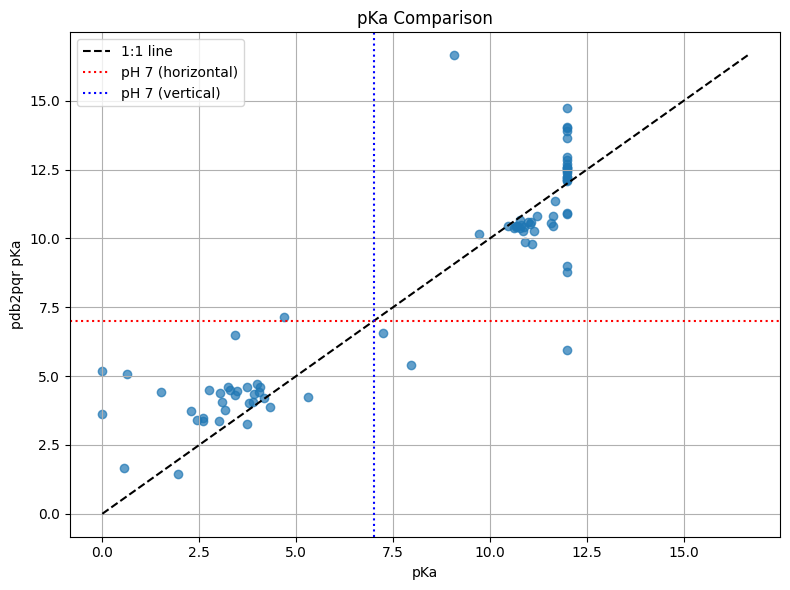

In [20]:
import matplotlib.pyplot as plt

# Load data from CSV file
# csv_file = ''  # Replace with actual path if different
# df = pd.read_csv(csv_file)
df = combined_df

# Extract axis labels based on column headers
x_col = 'pKa'
y_col = 'pdb2pqr pKa'

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(df[x_col], df[y_col], alpha=0.7)

# Axis labels
plt.xlabel(x_col)
plt.ylabel(y_col)

# 1:1 line
min_val = min(df[x_col].min(), df[y_col].min())
max_val = max(df[x_col].max(), df[y_col].max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='1:1 line')

# pH 7 reference lines
plt.axhline(7, color='red', linestyle=':', label='pH 7 (horizontal)')
plt.axvline(7, color='blue', linestyle=':', label='pH 7 (vertical)')

plt.legend()
plt.title("pKa Comparison")
plt.grid(True)
plt.tight_layout()

plt.show()


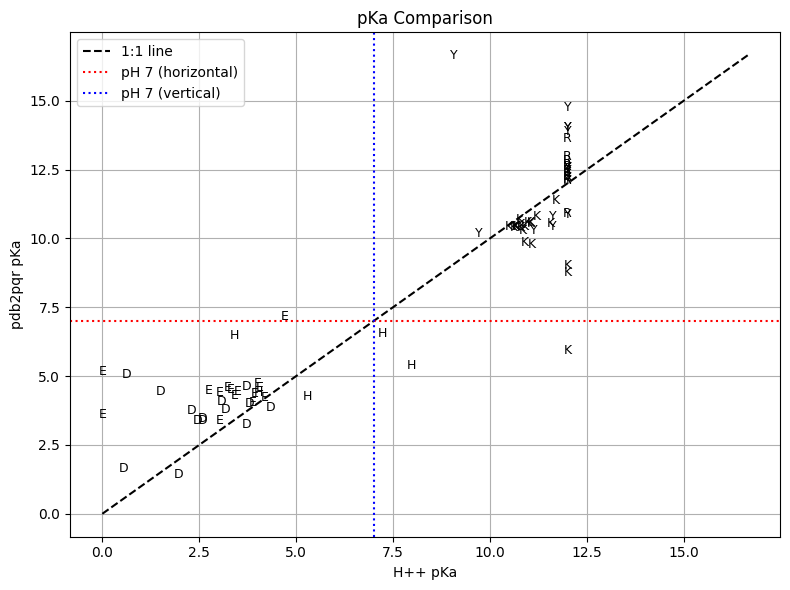

In [24]:
import matplotlib.pyplot as plt

# Assuming df is already loaded as `combined_df`
df = combined_df

# Extract axis labels based on column headers
x_col = 'pKa'
y_col = 'pdb2pqr pKa'

# Plotting
plt.figure(figsize=(8, 6))

# Plot each data point as its amino acid 1-letter code
for _, row in df.iterrows():
    label = row['amino acid'][0]  # First letter (1-letter code)
    plt.text(row[x_col], row[y_col], label, fontsize=9, ha='center', va='center')

# Axis labels
plt.xlabel('H++ pKa')
plt.ylabel(y_col)

# 1:1 line
min_val = min(df[x_col].min(), df[y_col].min())
max_val = max(df[x_col].max(), df[y_col].max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='1:1 line')

# pH 7 reference lines
plt.axhline(7, color='red', linestyle=':', label='pH 7 (horizontal)')
plt.axvline(7, color='blue', linestyle=':', label='pH 7 (vertical)')

plt.legend()
plt.title("pKa Comparison")
plt.grid(True)
plt.tight_layout()

plt.savefig("2r9w_pKa_comparison.png", dpi=300, bbox_inches='tight')
plt.show()
